# Training and Tuning Notebook

> В этом ноутбуке интерактивное обучение и оценка модели классификации изображений CIFAR-10, с использованием гиперпараметров подобраных с помощью Optuna.

# Импорт необходимых библиотек

In [3]:
import torch
import numpy as np
import random
from typing import Tuple, List
import torchvision.transforms as transforms
from torch.utils.data import DataLoader, random_split
from torchvision.datasets import CIFAR10
import torch.nn as nn
from torchvision.models.resnet import ResNet18_Weights
import torchvision.models as models
import torch.optim as optim
from torch.optim.lr_scheduler import ReduceLROnPlateau

## Добавление обработки CUDA и воспроизводимости:

In [4]:
random_seed: int = 42

torch.manual_seed(random_seed)
np.random.seed(random_seed)
random.seed(random_seed)

if torch.cuda.is_available():
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

## Загрузка и подготовка данных CIFAR-10

In [5]:
class CIFAR10DataLoader:
    def __init__(self, batch_size: int, num_workers: int = 2, random_seed: int = 42) -> None:
        self.batch_size = batch_size
        self.num_workers = num_workers
        self.random_seed = random_seed
        # ResNet18 uses this size as its input size.
        self.image_size = (224, 224)
        # For normalization.
        self.mean = (0.4914, 0.4822, 0.4465)
        self.std = (0.1953, 0.1925, 0.1942)

        # For reproducibility
        torch.manual_seed(self.random_seed)
        self.generator = torch.Generator().manual_seed(self.random_seed)

    def _get_transforms(self) -> Tuple[transforms.Compose, transforms.Compose]:
        """Creates transformations for training and test datasets."""
        transform_train = transforms.Compose([
            transforms.Resize(self.image_size),
            transforms.RandomCrop(self.image_size[0], padding=4),
            transforms.RandomHorizontalFlip(p=0.5),
            transforms.RandomRotation(15),
            transforms.ToTensor(),
            transforms.Normalize(self.mean, self.std),
        ])

        transform_test = transforms.Compose([
            transforms.Resize(self.image_size),
            transforms.ToTensor(),
            transforms.Normalize(self.mean, self.std),
        ])

        return transform_train, transform_test

    def load_data(self) -> Tuple[DataLoader, DataLoader, DataLoader]:
        """Loads, splits, and preprocesses the CIFAR-10 dataset."""
        transform_train, transform_test = self._get_transforms()

        # Load full training set
        full_trainset = CIFAR10(root='./data', train=True,
                                download=True, transform=transform_train)
        testset = CIFAR10(root='./data', train=False,
                          download=True, transform=transform_test)

        # Define dataset sizes
        train_size = int(0.8 * len(full_trainset))
        val_size = len(full_trainset) - train_size

        # Randomly split into training and validation sets
        trainset, valset = random_split(
            full_trainset, [train_size, val_size], generator=self.generator)

        def seed_worker(worker_id: int) -> None:
            """Initializes seed for each worker in DataLoader."""
            worker_seed = torch.initial_seed() % 2**32
            np.random.seed(worker_seed)
            random.seed(worker_seed)

        g = torch.Generator()
        g.manual_seed(self.random_seed)

        # Create data loaders
        trainloader = DataLoader(trainset, batch_size=self.batch_size,
                                 shuffle=True, num_workers=self.num_workers, pin_memory=True,
                                 worker_init_fn=seed_worker, generator=g)
        valloader = DataLoader(valset, batch_size=self.batch_size,
                               shuffle=False, num_workers=self.num_workers, pin_memory=True,
                               worker_init_fn=seed_worker, generator=g)
        testloader = DataLoader(testset, batch_size=self.batch_size,
                                shuffle=False, num_workers=self.num_workers, pin_memory=True,
                                worker_init_fn=seed_worker, generator=g)

        return trainloader, valloader, testloader

## Определение архитектуры ResNet18 с SE-блоками

In [6]:
class SEBlock(nn.Module):
    def __init__(self, channel: int, reduction: int = 16) -> None:
        super(SEBlock, self).__init__()
        self.avg_pool = nn.AdaptiveAvgPool2d(1)
        self.fc = nn.Sequential(
            nn.Linear(channel, channel // reduction, bias=False),
            nn.ReLU(inplace=True),
            nn.Linear(channel // reduction, channel, bias=False),
            nn.Sigmoid()
        )

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        b, c, _, _ = x.size()
        y = self.avg_pool(x).view(b, c)
        y = self.fc(y).view(b, c, 1, 1)
        return x * y.expand_as(x)


class ResNet18SE(nn.Module):
    def __init__(
        self,
        device: torch.device = torch.device("cpu"),
        pretrained: bool = True,
        num_classes: int = 10
    ) -> None:
        """Initialize a ResNet18 model with attention."""
        super(ResNet18SE, self).__init__()
        weights = ResNet18_Weights.DEFAULT if pretrained else None
        self.resnet = models.resnet18(weights=weights)

        # Freeze weights
        for param in self.resnet.parameters():
            param.requires_grad = False

        # Add SE blocks after each convolutional block
        self._add_se_blocks()

        # Replace the final fully connected layer
        num_ftrs = self.resnet.fc.in_features
        self.resnet.fc = nn.Linear(num_ftrs, num_classes)

        # Move the model to the specified device
        self.resnet.to(device)
        if torch.__version__ >= "2.0":  # Use torch.compile() for optimization
            self.resnet = torch.compile(self.resnet)

    def _add_se_blocks(self) -> None:
        """Adds SE blocks after each convolutional block."""
        channels = [64, 128, 256, 512]
        for i, (layer, channel) in enumerate(zip(
                (self.resnet.layer1, self.resnet.layer2, self.resnet.layer3, self.resnet.layer4), channels)):
            layer.add_module(f"{i}_se", SEBlock(channel))

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return self.resnet(x)

    def unfreeze_layers(self, num_layers: int) -> None:
        """Unfreezes the last num_layers layers for fine-tuning."""
        layers = [self.resnet.layer1, self.resnet.layer2,
                  self.resnet.layer3, self.resnet.layer4]
        for layer in layers[-num_layers:]:
            for param in layer.parameters():
                param.requires_grad = True

## Класс для обучения модели

In [7]:
class ModelTrainer:
    def __init__(self, model: nn.Module, device: torch.device, random_seed: int = 42):
        self.model = model
        self.device = device
        self.random_seed = random_seed
        torch.manual_seed(self.random_seed)

    def train(self, trainloader: DataLoader, valloader: DataLoader,
              learning_rate: float, num_epochs: int,
              weight_decay: float, patience: int) -> Tuple[List[float], List[float]]:
        """Trains the model and returns its training history."""
        self.model.to(self.device)
        criterion = nn.CrossEntropyLoss().to(self.device)
        optimizer = optim.Adam(self.model.parameters(),
                               lr=learning_rate, weight_decay=weight_decay)
        scheduler = ReduceLROnPlateau(
            optimizer, mode='max', factor=0.1, patience=patience // 2, min_lr=0)

        train_losses = []
        val_accuracies = []
        best_val_accuracy = float('-inf')
        epochs_no_improve = 0

        for epoch in range(num_epochs):
            self.model.train()
            running_loss = 0.0
            for inputs, labels in trainloader:
                inputs, labels = inputs.to(self.device), labels.to(self.device)

                optimizer.zero_grad()
                outputs = self.model(inputs)
                loss = criterion(outputs, labels)
                loss.backward()
                optimizer.step()

                running_loss += loss.item()

            train_loss = running_loss / len(trainloader)
            train_losses.append(train_loss)
            print(
                f"Epoch {epoch+1}/{num_epochs}, Training Loss: {train_loss:.4f}")

            # Evaluate on validation set
            val_accuracy = self.evaluate(valloader)
            val_accuracies.append(val_accuracy)

            # Early stopping
            if val_accuracy > best_val_accuracy:
                best_val_accuracy = val_accuracy
                epochs_no_improve = 0
                best_model_state = self.model.state_dict()
            else:
                epochs_no_improve += 1
                if epochs_no_improve == patience:
                    print(
                        f"Early stopping! No improvement for {patience} epochs.")
                    self.model.load_state_dict(best_model_state)
                    break

            scheduler.step(val_accuracy)
            current_lr = scheduler.get_last_lr()[0]
            if current_lr < learning_rate:
                print(f"Learning rate reduced to: {current_lr}")

        return train_losses, val_accuracies

    def evaluate(self, dataloader: DataLoader) -> float:
        """Evaluates the model on the given dataloader and returns the accuracy."""
        self.model.eval()
        correct = 0
        total = 0
        with torch.no_grad():
            for inputs, labels in dataloader:
                inputs, labels = inputs.to(self.device), labels.to(self.device)
                outputs = self.model(inputs)
                _, predicted = torch.max(outputs.data, 1)
                total += labels.size(0)
                correct += (predicted == labels).sum().item()

        accuracy = 100 * correct / total
        print(f"Validation Accuracy: {accuracy:.2f}%")
        return accuracy

## Оценка модели

In [8]:
def evaluate_test(
    model: torch.nn.Module,
    test_loader: DataLoader,
    device: torch.device,
) -> Tuple[List[int], List[int]]:
    """Evaluate a model on a given test dataset."""
    model.eval()
    true_labels = []
    predicted_labels = []
    with torch.no_grad():
        for images, labels in test_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            _, predicted = torch.max(outputs, 1)
            true_labels.extend(labels.cpu().numpy())
            predicted_labels.extend(predicted.cpu().numpy())

    return true_labels, predicted_labels

## Загрузка лучших гиперпараметров

In [9]:
import json
import os
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix
import seaborn as sns

with open("best_params.json", "r") as f:
    best_params = json.load(f)

print("Лучшие гиперпараметры загружены:")
print(best_params)

Лучшие гиперпараметры загружены:
{'lr': 6.5945635866259e-05, 'batch_size': 32, 'wd': 0.00011469106617371565, 'epochs': 14, 'patience': 5, 'num_layers_to_unfreeze': 3}


## Инициализация и обучение модели

In [14]:
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
num_workers = os.cpu_count() or 2

loader = CIFAR10DataLoader(
    batch_size=best_params["batch_size"], num_workers=num_workers, random_seed=42)
trainloader, valloader, testloader = loader.load_data()

best_model = ResNet18SE(device)
for param in best_model.parameters():
    param.requires_grad = False

best_model.unfreeze_layers(num_layers=best_params["num_layers_to_unfreeze"])

trainer = ModelTrainer(best_model, device, random_seed=42)
print("Обучение ResNet18 с SE...")
train_losses, history_df = trainer.train(
    trainloader, valloader,
    learning_rate=best_params["lr"],
    num_epochs=best_params["epochs"],
    weight_decay=best_params["wd"],
    patience=best_params["patience"]
)

Обучение ResNet18 с SE...


W0404 13:12:24.652000 217 torch/_inductor/utils.py:1137] [0/0] Not enough SMs to use max_autotune_gemm mode


Epoch 1/14, Training Loss: 0.4721
Validation Accuracy: 92.26%
Epoch 2/14, Training Loss: 0.2159
Validation Accuracy: 93.36%
Epoch 3/14, Training Loss: 0.1529
Validation Accuracy: 94.25%
Epoch 4/14, Training Loss: 0.1186
Validation Accuracy: 94.66%
Epoch 5/14, Training Loss: 0.0965
Validation Accuracy: 94.22%
Epoch 6/14, Training Loss: 0.0875
Validation Accuracy: 94.54%
Epoch 7/14, Training Loss: 0.0709
Validation Accuracy: 94.67%
Epoch 8/14, Training Loss: 0.0624
Validation Accuracy: 95.00%
Epoch 9/14, Training Loss: 0.0577
Validation Accuracy: 94.86%
Epoch 10/14, Training Loss: 0.0524
Validation Accuracy: 95.08%
Epoch 11/14, Training Loss: 0.0460
Validation Accuracy: 93.38%
Epoch 12/14, Training Loss: 0.0412
Validation Accuracy: 95.03%
Epoch 13/14, Training Loss: 0.0438
Validation Accuracy: 95.29%
Epoch 14/14, Training Loss: 0.0400
Validation Accuracy: 95.23%


## Оценка модели на тестовом наборе

In [15]:
y_true, y_pred = evaluate_test(best_model, testloader, device)
val_accuracy = 100 * np.mean(np.array(y_true) == np.array(y_pred))
print(f"Test accuracy: {val_accuracy:.2f}%")

Test accuracy: 95.08%


## Визуализация результатов

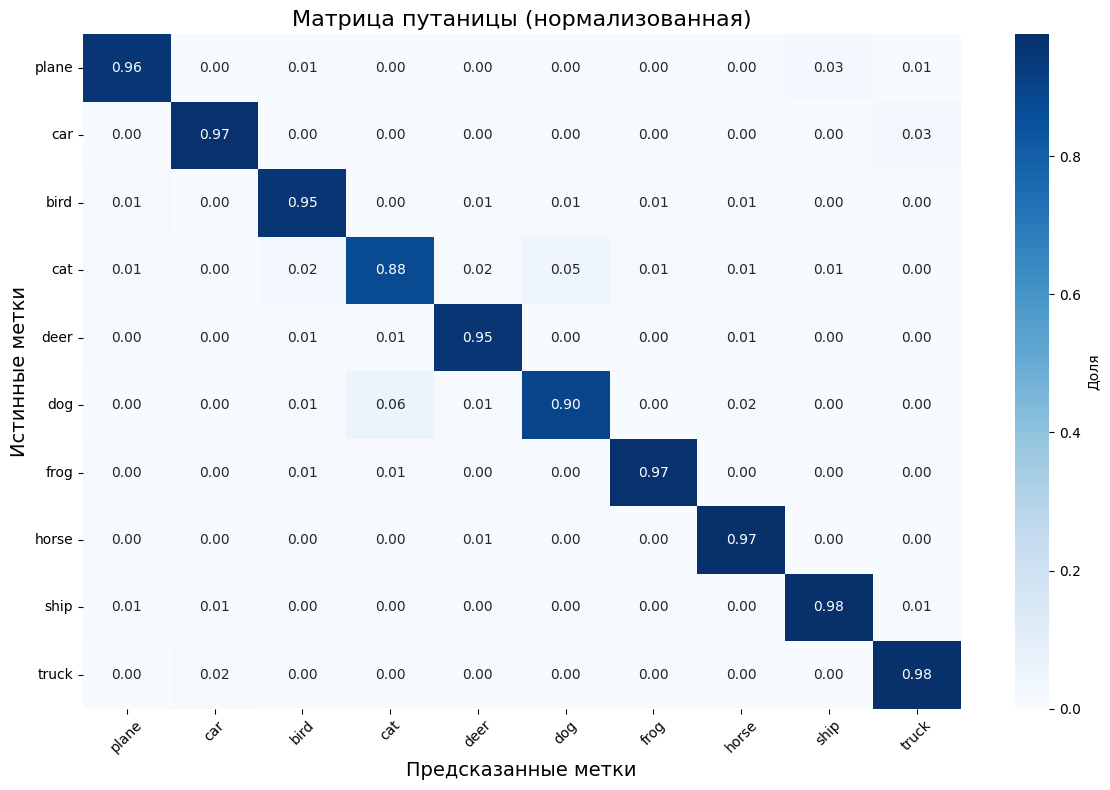

In [16]:
def plot_confusion_matrix(true_labels, predicted_labels, class_names):
    cm = confusion_matrix(true_labels, predicted_labels)
    plt.figure(figsize=(12, 8))

    # Нормализация матрицы путаницы для отображения процентов
    cm_normalized = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]

    sns.heatmap(cm_normalized, annot=True, fmt='.2f', cmap='Blues',
                xticklabels=class_names, yticklabels=class_names, cbar_kws={'label': 'Доля'})

    plt.ylabel('Истинные метки', fontsize=14)
    plt.xlabel('Предсказанные метки', fontsize=14)
    plt.title('Матрица путаницы (нормализованная)', fontsize=16)
    plt.xticks(rotation=45)
    plt.yticks(rotation=0)
    plt.tight_layout()
    plt.show()


class_names = ('plane', 'car', 'bird', 'cat', 'deer',
               'dog', 'frog', 'horse', 'ship', 'truck')
plot_confusion_matrix(y_true, y_pred, class_names)

In [18]:
sns.set(style="whitegrid")


def plot_validation_accuracy(
    validation_accuracies: List[float],
    epochs: List[int] = list(range(1, best_params["epochs"] + 1)),
) -> None:
    """Plot validation accuracy for model."""
    plt.figure(figsize=(12, 6))

    # Plot accuracy for model
    plt.plot(epochs, validation_accuracies, marker='o',
             color='b', label='Validation Accuracy', linewidth=2)

    plt.xlabel('Epoch', fontsize=14)
    plt.ylabel('Validation Accuracy (%)', fontsize=14)
    plt.title('Model Validation Accuracy', fontsize=16)
    plt.xticks(epochs)
    plt.axhline(y=max(validation_accuracies), color='r', linestyle='--',
                label='Max Accuracy')
    plt.legend(fontsize=12)
    plt.grid(True)
    plt.tight_layout()
    plt.show()


def plot_loss(
    training_losses: List[float],
    epochs: List[int] = list(range(1, best_params["epochs"] + 1)),
) -> None:
    """Plot training loss for models."""
    plt.figure(figsize=(12, 6))

    # Plot loss for model
    plt.plot(epochs, training_losses, marker='x',
             color='g', label='Training Loss', linewidth=2)

    plt.xlabel('Epoch', fontsize=14)
    plt.ylabel('Training Loss', fontsize=14)
    plt.title('Model Training Loss', fontsize=16)
    plt.xticks(epochs)
    plt.axhline(y=min(training_losses), color='r',
                linestyle='--', label='Min Loss')
    plt.legend(fontsize=12)
    plt.grid(True)
    plt.tight_layout()
    plt.show()

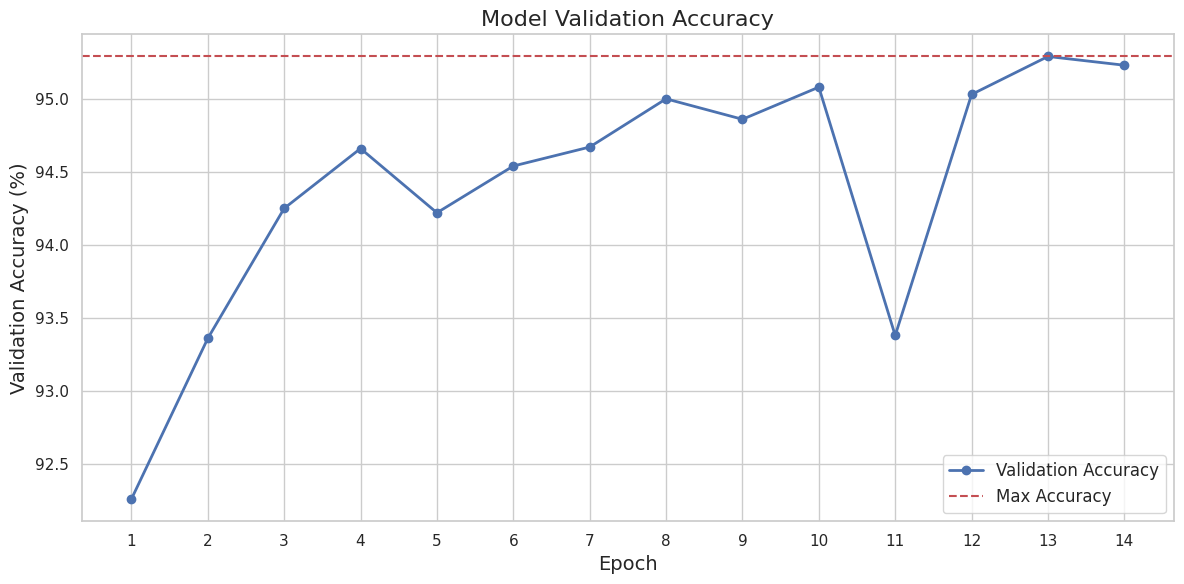

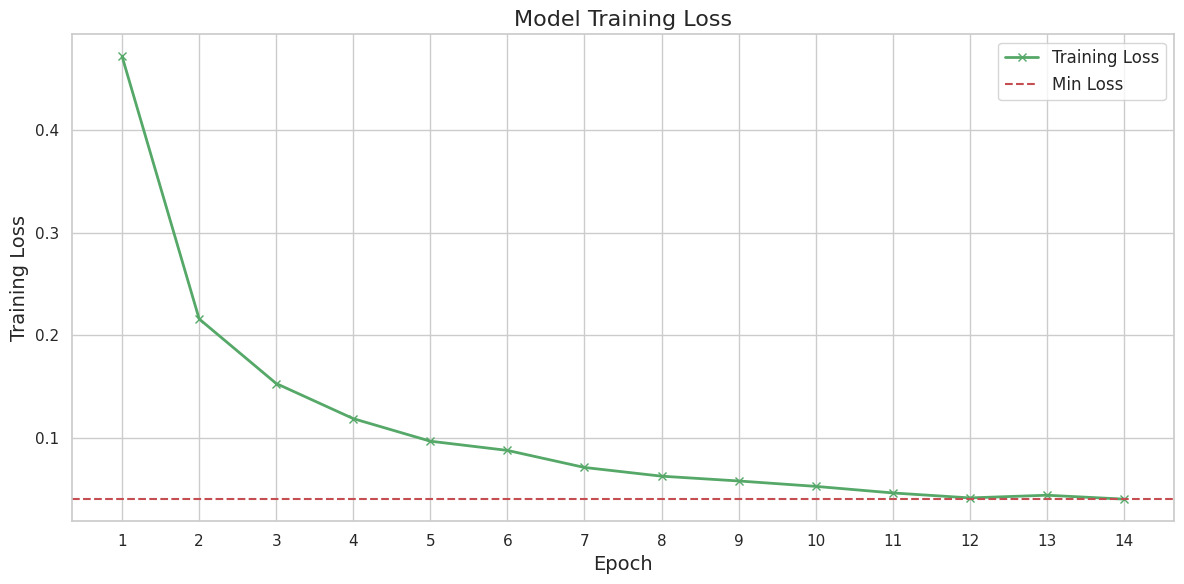

In [19]:
plot_validation_accuracy(history_df)
plot_loss(train_losses)

## Сохранение модели

In [20]:
torch.save(best_model.state_dict(), 'model.pth')
print("Модель сохранена как model.pth")

Модель сохранена как model.pth


## Загрузка модели для дальнейших предсказаний

In [21]:
def load_model(model_path):
    model = ResNet18SE(num_classes=len(class_names))
    model.load_state_dict(torch.load(model_path, map_location=device))
    model.eval()
    return model

## Пример предсказания

In [22]:
MEAN = (0.4914, 0.4822, 0.4465)
STD = (0.1953, 0.1925, 0.1942)

# Define transformations
transform_test = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(MEAN, STD),
])

In [23]:
def predict_random_image(model):
    """Predicts the class of a random image from the CIFAR-10 test dataset."""
    cifar10_dataset = CIFAR10(root='./data', train=False,
                              download=True, transform=transform_test)
    random_index = np.random.randint(len(cifar10_dataset))
    image, label = cifar10_dataset[random_index]
    image = image.to(device).unsqueeze(0)

    # Make prediction
    model.eval()  # Ensure the model is in evaluation mode
    with torch.no_grad():  # Disable gradient calculation
        output = model(image)
        _, predicted = torch.max(output.data, 1)
        predicted_class = class_names[predicted[0]]

    # Display the image and prediction
    img = image.squeeze().cpu().numpy()  # Remove batch dimension
    img = np.transpose(img, (1, 2, 0))  # Change to HWC format

    img = STD * img + MEAN
    img = np.clip(img, 0, 1)

    plt.imshow(img)
    plt.title(
        f"Истинная метка: {class_names[label]}, Предсказанная метка: {predicted_class}")
    plt.axis('off')
    plt.show()

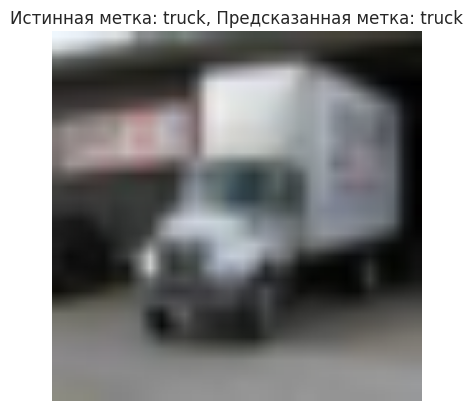

In [25]:
predict_random_image(best_model)